In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('../data/features.csv')

# features and target
X = df[['nitrogen_load', 'sst_c']]
y = df['area_km2']

# Leave-One-Out cross validation (best for small datasets like this)
loo = LeaveOneOut()
predictions = []
actuals = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    predictions.append(model.predict(X_test)[0])
    actuals.append(y_test.values[0])

df['predicted'] = predictions
df['residual'] = df['area_km2'] - df['predicted']

r2 = r2_score(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)

print(f"R²:  {r2:.3f}")
print(f"MAE: {mae:.0f} km²")

R²:  0.515
MAE: 2517 km²


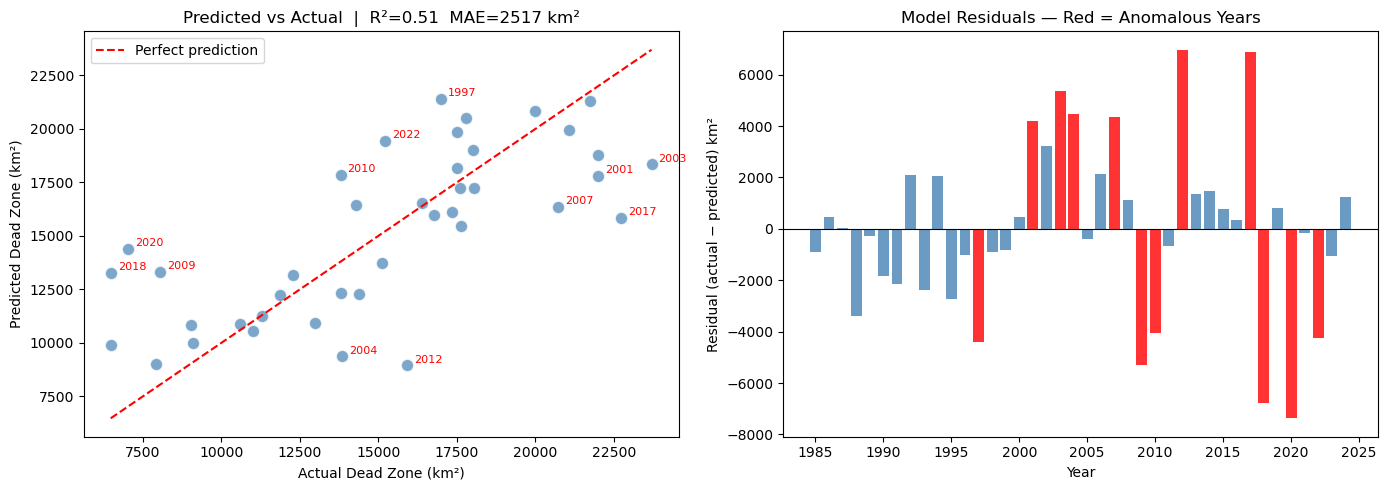

Most anomalous years (residual > 4000 km²):
 year  area_km2  predicted  residual
 1997     17000   21397.12  -4397.12
 2001     22000   17794.70   4205.30
 2003     23700   18344.46   5355.54
 2004     13840    9374.70   4465.30
 2007     20720   16352.20   4367.80
 2009      8040   13338.80  -5298.80
 2010     13800   17853.80  -4053.80
 2012     15920    8950.30   6969.70
 2017     22720   15831.60   6888.40
 2018      6480   13273.60  -6793.60
 2020      7030   14402.60  -7372.60
 2022     15220   19452.44  -4232.44


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: predicted vs actual
axes[0].scatter(df['area_km2'], df['predicted'], color='steelblue', alpha=0.7, s=80, edgecolors='white')
axes[0].plot([df['area_km2'].min(), df['area_km2'].max()],
             [df['area_km2'].min(), df['area_km2'].max()],
             'r--', linewidth=1.5, label='Perfect prediction')
for _, row in df.iterrows():
    if abs(row['residual']) > 4000:
        axes[0].annotate(str(int(row['year'])),
                         (row['area_km2'], row['predicted']),
                         fontsize=8, color='red',
                         textcoords='offset points', xytext=(5, 2))
axes[0].set_xlabel('Actual Dead Zone (km²)')
axes[0].set_ylabel('Predicted Dead Zone (km²)')
axes[0].set_title(f'Predicted vs Actual  |  R²={r2:.2f}  MAE={mae:.0f} km²')
axes[0].legend()

# right: residuals over time — anomaly story
colors = ['red' if abs(r) > 4000 else 'steelblue' for r in df['residual']]
axes[1].bar(df['year'], df['residual'], color=colors, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Residual (actual − predicted) km²')
axes[1].set_title('Model Residuals — Red = Anomalous Years')

plt.tight_layout()
plt.savefig('../outputs/model_results.png', dpi=150)
plt.show()

# print the anomalous years
print("Most anomalous years (residual > 4000 km²):")
print(df[abs(df['residual']) > 4000][['year', 'area_km2', 'predicted', 'residual']].to_string(index=False))

In [4]:
# annotated anomaly explanation
anomalies = {
    1997: "La Niña year — reduced river flow shrunk the zone",
    2001: "Above average: record nutrient loading that spring",
    2003: "Above average: high May discharge, warm stratification",
    2004: "Below average: Hurricane Ivan disrupted stratification",
    2009: "Below average: La Niña, low spring river discharge",
    2010: "Below average: Deepwater Horizon oil spill — cruise area restricted",
    2012: "Above average: severe Midwest drought cut runoff but zone still large",
    2017: "RECORD zone (22,720 km²) — extreme spring flooding, record N load",
    2018: "Below average: Hurricane Michael + wind mixing broke up the zone",
    2020: "Below average: Hurricane Hanna hit days before the survey cruise",
    2022: "Below average: drought conditions in Mississippi watershed",
}

print("Anomalous years and their causes:\n")
for year, reason in anomalies.items():
    row = df[df['year'] == year].iloc[0]
    direction = "LARGER" if row['residual'] > 0 else "SMALLER"
    print(f"{year} ({direction} than predicted by {abs(row['residual']):.0f} km²)")
    print(f"  → {reason}\n")

Anomalous years and their causes:

1997 (SMALLER than predicted by 4397 km²)
  → La Niña year — reduced river flow shrunk the zone

2001 (LARGER than predicted by 4205 km²)
  → Above average: record nutrient loading that spring

2003 (LARGER than predicted by 5356 km²)
  → Above average: high May discharge, warm stratification

2004 (LARGER than predicted by 4465 km²)
  → Below average: Hurricane Ivan disrupted stratification

2009 (SMALLER than predicted by 5299 km²)
  → Below average: La Niña, low spring river discharge

2010 (SMALLER than predicted by 4054 km²)
  → Below average: Deepwater Horizon oil spill — cruise area restricted

2012 (LARGER than predicted by 6970 km²)
  → Above average: severe Midwest drought cut runoff but zone still large

2017 (LARGER than predicted by 6888 km²)
  → RECORD zone (22,720 km²) — extreme spring flooding, record N load

2018 (SMALLER than predicted by 6794 km²)
  → Below average: Hurricane Michael + wind mixing broke up the zone

2020 (SMALLER th

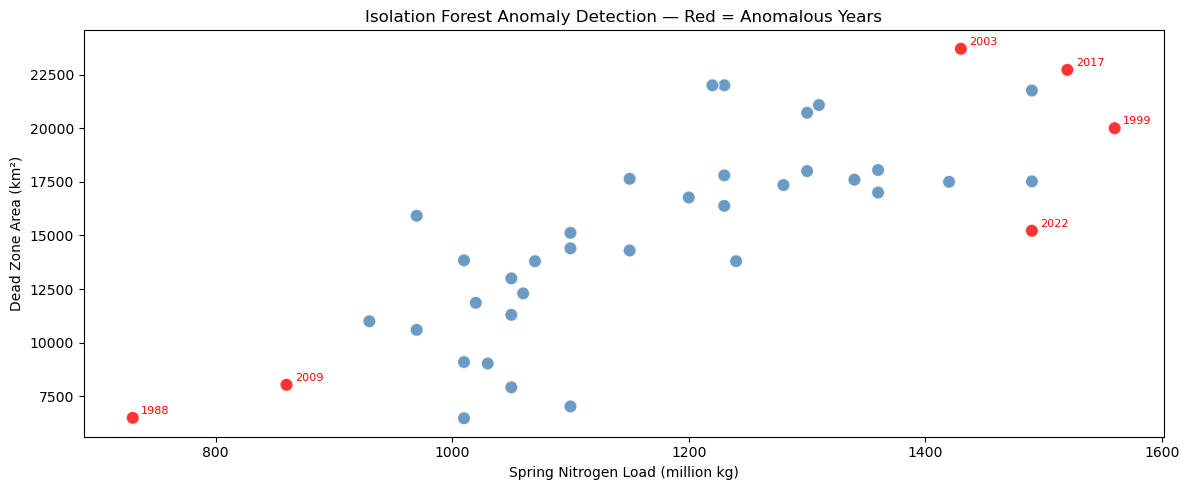


Anomaly years flagged by Isolation Forest:
 year  area_km2  nitrogen_load
 1988      6500            730
 1999     20000           1560
 2003     23700           1430
 2009      8040            860
 2017     22720           1520
 2022     15220           1490


In [5]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.15, random_state=42)
df['anomaly'] = iso.fit_predict(df[['nitrogen_load', 'area_km2']])
df['anomaly_label'] = df['anomaly'].map({1: 'normal', -1: 'anomaly'})

plt.figure(figsize=(12, 5))
colors = df['anomaly'].map({1: 'steelblue', -1: 'red'})
plt.scatter(df['nitrogen_load'], df['area_km2'], c=colors, s=90, alpha=0.8, edgecolors='white')
for _, row in df[df['anomaly'] == -1].iterrows():
    plt.annotate(str(int(row['year'])),
                 (row['nitrogen_load'], row['area_km2']),
                 fontsize=8, color='red',
                 textcoords='offset points', xytext=(6, 3))
plt.xlabel('Spring Nitrogen Load (million kg)')
plt.ylabel('Dead Zone Area (km²)')
plt.title('Isolation Forest Anomaly Detection — Red = Anomalous Years')
plt.tight_layout()
plt.savefig('../outputs/anomaly_detection.png', dpi=150)
plt.show()

print("\nAnomaly years flagged by Isolation Forest:")
print(df[df['anomaly'] == -1][['year', 'area_km2', 'nitrogen_load']].to_string(index=False))

In [6]:
import joblib

# train final model on all data
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(X, y)

# feature importance
importances = pd.Series(final_model.feature_importances_, index=X.columns)
print("Feature importances:")
print(importances.sort_values(ascending=False))

# save model and feature table
joblib.dump(final_model, '../data/model.pkl')
df.to_csv('../data/features_with_predictions.csv', index=False)
print("\nModel and data saved.")

Feature importances:
nitrogen_load    0.804341
sst_c            0.195659
dtype: float64

Model and data saved.
